# Plan for today

- Download price data of multiple stocks
- Compute Daily and Monthly returns
- Compute Correlations
- Compute Cumulative Returns
- Annualized Returns and Risk (std. deviation)

In [1]:
# Installation of python modules

!pip install pandas
!pip install numpy
!pip install yfinance
!pip install matplotlib
!pip install plotly

In [2]:
# @title
# Importing data manipulation modules
import pandas as pd
import numpy as np

# Importing data visulations modules
import matplotlib.pyplot as plt

# Importing finance modules
import yfinance as yf

# Download data

We will be using a free python api library called [y-finance](https://pypi.org/project/yfinance/) and is a popular open-source library that allows users to download historical market data from Yahoo Finance. It simplifies the process of accessing financial data for stocks, bonds, and other assets, providing both historical and real-time data for analysis, research, and modeling.

Although, it is great for experimentation it is too unreliable to be used in the actaul implementation of algos due to rate limiting, throttling and data inaccuracy.

In [3]:
# Ticker list to download
tickers = 'SPY QQQ TLT AAPL MSFT GOOG AMZN NFLX NVDA MA ADBE' # Why would we use these instead of just company names?

# Download data from Yahoo-Finance
data = yf.download(
    tickers = tickers, # The stocks do we want to get
    interval = "1d", # The sample rate of the data
    start="2020-01-01", # From what point do we want to start getting stock data
    end="2024-04-30", # From what point do we want to stop getting stock data
    ignore_tz=True,
    auto_adjust=True, # Adjust all fields by splits and dividends
)

[*********************100%***********************]  11 of 11 completed


In [4]:
# What data does y-finance give us?
data

Price            Close                                                  \
Ticker            AAPL        ADBE        AMZN        GOOG          MA   
Date                                                                     
2020-01-02   72.400497  334.429993   94.900497   67.811760  292.898499   
2020-01-03   71.696632  331.809998   93.748497   67.479004  290.040894   
2020-01-06   72.267921  333.709991   95.143997   69.142838  290.813263   
2020-01-07   71.928055  333.390015   95.343002   69.099701  289.828552   
2020-01-08   73.085114  337.869995   94.598503   69.644226  294.942322   
...                ...         ...         ...         ...         ...   
2024-04-23  165.394791  472.899994  179.539993  158.617767  458.197083   
2024-04-24  167.495636  477.119995  176.589996  159.788162  457.880249   
2024-04-25  168.357803  473.440002  173.669998  156.663803  457.494141   
2024-04-26  167.773102  477.559998  179.619995  172.275635  457.801056   
2024-04-29  171.935242  473.070007  180.960007  166.532761  452.534210   

Price                                                                 ...  \
Ticker            MSFT       NFLX       NVDA         QQQ         SPY  ...   
Date                                                                  ...   
2020-01-02  152.158356  32.980999   5.970755  208.580200  297.699036  ...   
2020-01-03  150.263779  32.590000   5.875186  206.669617  295.444702  ...   
2020-01-06  150.652145  33.583000   5.899823  208.001221  296.571930  ...   
2020-01-07  149.278534  33.075001   5.971253  207.972305  295.738007  ...   
2020-01-08  151.656372  33.925999   5.982451  209.535477  297.314148  ...   
...                ...        ...        ...         ...         ...  ...   
2024-04-23  401.408905  57.775002  82.376518  420.982544  494.984467  ...   
2024-04-24  402.876343  55.512001  79.632065  422.408691  494.749542  ...   
2024-04-25  393.007874  56.480000  82.585396  420.368530  492.870056  ...   
2024-04-26  400.177826  56.123001  87.685516  426.855530  497.539459  ...   
2024-04-29  396.169342  55.949001  87.707520  428.588745  499.301453  ...   

Price        Volume                                                   \
Ticker         ADBE      AMZN      GOOG       MA      MSFT      NFLX   
Date                                                                   
2020-01-02  1990100  80580000  28132000  3272400  22622100  44858000   
2020-01-03  1577600  75288000  23728000  2501300  21116200  38069000   
2020-01-06  1874700  81236000  34646000  3307200  20813700  56631000   
2020-01-07  2500800  80898000  30054000  3182000  21634100  47032000   
2020-01-08  2248500  70160000  30560000  3224400  27746500  71045000   
...             ...       ...       ...      ...       ...       ...   
2024-04-23  2205800  37046500  16115400  2029100  15734500  49755000   
2024-04-24  2338000  34185100  19485700  4043100  15065300  53553000   
2024-04-25  2250900  49249400  36197800  2006500  40586500  38071000   
2024-04-26  2460300  43919800  56500800  1963300  29694700  43326000   
2024-04-29  2954700  54063900  35914600  2120700  19582100  25089000   

Price                                                
Ticker           NVDA       QQQ       SPY       TLT  
Date                                                 
2020-01-02  237536000  30969400  59151200  11034100  
2020-01-03  205384000  27518900  77709700  12366000  
2020-01-06  262636000  21655300  55653900  11369800  
2020-01-07  314856000  22139300  40496400   8381200  
2020-01-08  277108000  26397300  68296000  10621700  
...               ...       ...       ...       ...  
2024-04-23  438559000  44384700  64633600  27222700  
2024-04-24  512208000  48440300  55928100  48986800  
2024-04-25  424641000  57392200  69122400  49282600  
2024-04-26  551011000  41874900  64306100  31589800  
2024-04-29  388971000  30022200  46415400  39228600  

[1088 rows x 55 columns]

In [5]:
print(data.columns)

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'ADBE'),
            ( 'Close', 'AMZN'),
            ( 'Close', 'GOOG'),
            ( 'Close',   'MA'),
            ( 'Close', 'MSFT'),
            ( 'Close', 'NFLX'),
            ( 'Close', 'NVDA'),
            ( 'Close',  'QQQ'),
            ( 'Close',  'SPY'),
            ( 'Close',  'TLT'),
            (  'High', 'AAPL'),
            (  'High', 'ADBE'),
            (  'High', 'AMZN'),
            (  'High', 'GOOG'),
            (  'High',   'MA'),
            (  'High', 'MSFT'),
            (  'High', 'NFLX'),
            (  'High', 'NVDA'),
            (  'High',  'QQQ'),
            (  'High',  'SPY'),
            (  'High',  'TLT'),
            (   'Low', 'AAPL'),
            (   'Low', 'ADBE'),
            (   'Low', 'AMZN'),
            (   'Low', 'GOOG'),
            (   'Low',   'MA'),
            (   'Low', 'MSFT'),
            (   'Low', 'NFLX'),
            (   'Low', 'NVDA'),
            (   'Low',  'QQQ'),
        

In [6]:
# Using the inbuilt pandas function describe() to give a description of the Close data
data['Close'].describe()

Ticker,AAPL,ADBE,AMZN,GOOG,MA,MSFT,NFLX,NVDA,QQQ,SPY,TLT
count,1088.000000,1088.000000,1088.000000,1088.000000,1088.000000,1088.000000,1088.000000,1088.000000,1088.000000,1088.000000,1088.000000
mean,140.900560,466.359026,139.736024,110.601573,348.836873,265.236208,43.173075,25.190086,316.280731,383.397114,110.302816
std,33.767852,100.201610,28.020436,26.454930,46.895266,65.527583,12.375257,18.734415,59.532876,59.818647,20.277427
min,54.213600,275.200012,81.820000,52.400795,196.531601,128.636398,16.636999,4.890823,163.363419,205.504578,74.837944
25%,122.357985,377.235001,115.859873,88.631716,321.963257,218.316608,34.247250,13.257148,276.868294,350.775696,90.767611
50%,145.262314,470.039993,146.082001,113.756821,346.841736,257.974030,44.035000,18.747353,315.065186,391.677063,115.411018
75%,168.494400,531.047516,163.465496,134.665665,370.303810,311.698280,52.072500,29.344315,359.689430,423.087936,128.163689
max,196.073105,688.369995,189.050003,172.275635,483.090027,422.879333,69.168999,94.948410,442.087616,512.135010,144.897537


In [7]:
# Using the inbuilt pandas function describe() to give a description of the Close data
data['Volume'].describe()

Ticker,AAPL,ADBE,AMZN,GOOG,MA,MSFT,NFLX,NVDA,QQQ,SPY,TLT
count,1.088000e+03,1.088000e+03,1.088000e+03,1.088000e+03,1.088000e+03,1.088000e+03,1.088000e+03,1.088000e+03,1.088000e+03,1.088000e+03,1.088000e+03
mean,9.605686e+07,3.063671e+06,7.293792e+07,2.885005e+07,3.607790e+06,3.000902e+07,6.837858e+07,4.683952e+08,5.219757e+07,8.670767e+07,2.141984e+07
std,5.352541e+07,1.806880e+06,3.381662e+07,1.273774e+07,1.892932e+06,1.282452e+07,6.636641e+07,1.872222e+08,2.248757e+07,4.198993e+07,1.409765e+07
min,2.404830e+07,5.892000e+05,2.237840e+07,6.936000e+06,9.444000e+05,9.200800e+06,1.144000e+07,9.788400e+07,1.549880e+07,2.645790e+07,3.117100e+06
25%,6.087352e+07,2.078650e+06,5.077100e+07,2.047475e+07,2.403075e+06,2.184642e+07,3.676025e+07,3.430572e+08,3.656578e+07,6.200395e+07,1.192592e+07
50%,8.144755e+07,2.598150e+06,6.385000e+07,2.558310e+07,3.095300e+06,2.675055e+07,5.277100e+07,4.472735e+08,4.794995e+07,7.669410e+07,1.752070e+07
75%,1.126557e+08,3.508225e+06,8.526510e+07,3.321350e+07,4.103675e+06,3.393732e+07,7.809450e+07,5.692942e+08,6.280010e+07,9.763808e+07,2.554638e+07
max,4.265100e+08,2.784020e+07,3.113460e+08,9.779860e+07,1.503150e+07,9.701270e+07,1.333875e+09,1.543911e+09,1.986858e+08,3.922207e+08,8.897510e+07


As we are only interested interested in the closing price on the day we will select this parameter and create a new DataFrame

In [8]:
# Copy the close data over to a new dataframe
df = data['Close'].copy()

In [9]:
# Display our data using the head(num_of_values) functions
df.head(10)

Ticker,AAPL,ADBE,AMZN,GOOG,MA,MSFT,NFLX,NVDA,QQQ,SPY,TLT
Date,,,,,,,,,,,
2020-01-02,72.400497,334.429993,94.900497,67.811760,292.898499,152.158356,32.980999,5.970755,208.580200,297.699036,114.622681
2020-01-03,71.696632,331.809998,93.748497,67.479004,290.040894,150.263779,32.590000,5.875186,206.669617,295.444702,116.387917
2020-01-06,72.267921,333.709991,95.143997,69.142838,290.813263,150.652145,33.583000,5.899823,208.001221,296.571930,115.727036
2020-01-07,71.928055,333.390015,95.343002,69.099701,289.828552,149.278534,33.075001,5.971253,207.972305,295.738007,115.158104
2020-01-08,73.085114,337.869995,94.598503,69.644226,294.942322,151.656372,33.925999,5.982451,209.535477,297.314148,114.396797
2020-01-09,74.637489,340.450012,95.052498,70.413406,298.809204,153.550949,33.566002,6.048155,211.310989,299.330048,114.798378
2020-01-10,74.806221,339.809998,94.157997,70.904388,300.810303,152.840469,32.904999,6.080509,210.770660,298.468719,115.819008
2020-01-13,76.404419,345.630005,94.565002,71.375511,304.715851,154.678299,33.891998,6.271146,213.202255,300.521454,115.467667
2020-01-14,75.372704,344.630005,93.472000,70.961418,300.298035,153.588867,33.868999,6.154175,212.362717,300.063171,116.061600


In [10]:
# Check to see how many null (no values) we have in our data (it should be 0 if y-finance has worked)
print(f"There are {df.isnull().sum().sum()} null values across the DataFrame")

# If we did have any rows with null in we would use the next line to remove them:
df[df.notnull().all(1)].head()




There are 0 null values across the DataFrame


Ticker,AAPL,ADBE,AMZN,GOOG,MA,MSFT,NFLX,NVDA,QQQ,SPY,TLT
Date,,,,,,,,,,,
2020-01-02,72.400497,334.429993,94.900497,67.811760,292.898499,152.158356,32.980999,5.970755,208.580200,297.699036,114.622681
2020-01-03,71.696632,331.809998,93.748497,67.479004,290.040894,150.263779,32.590000,5.875186,206.669617,295.444702,116.387917
2020-01-06,72.267921,333.709991,95.143997,69.142838,290.813263,150.652145,33.583000,5.899823,208.001221,296.571930,115.727036
2020-01-07,71.928055,333.390015,95.343002,69.099701,289.828552,149.278534,33.075001,5.971253,207.972305,295.738007,115.158104
2020-01-08,73.085114,337.869995,94.598503,69.644226,294.942322,151.656372,33.925999,5.982451,209.535477,297.314148,114.396797


Now let's compute a very simple metric called daily returns

In [11]:
# Using pandas inbuilt function pct_change to compute the daily returns for us
df = df.pct_change()
df.head()

Ticker,AAPL,ADBE,AMZN,GOOG,MA,MSFT,NFLX,NVDA,QQQ,SPY,TLT
Date,,,,,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.009722,-0.007834,-0.012139,-0.004907,-0.009756,-0.012451,-0.011855,-0.016006,-0.009160,-0.007573,0.015400
2020-01-06,0.007968,0.005726,0.014886,0.024657,0.002663,0.002585,0.030469,0.004193,0.006443,0.003815,-0.005678
2020-01-07,-0.004703,-0.000959,0.002092,-0.000624,-0.003386,-0.009118,-0.015127,0.012107,-0.000139,-0.002812,-0.004916
2020-01-08,0.016086,0.013438,-0.007809,0.007880,0.017644,0.015929,0.025729,0.001875,0.007516,0.005330,-0.006611


In [12]:
# Fill the first row with zero
df = df.fillna(0)

In [13]:
df.head()

Ticker,AAPL,ADBE,AMZN,GOOG,MA,MSFT,NFLX,NVDA,QQQ,SPY,TLT
Date,,,,,,,,,,,
2020-01-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2020-01-03,-0.009722,-0.007834,-0.012139,-0.004907,-0.009756,-0.012451,-0.011855,-0.016006,-0.009160,-0.007573,0.015400
2020-01-06,0.007968,0.005726,0.014886,0.024657,0.002663,0.002585,0.030469,0.004193,0.006443,0.003815,-0.005678
2020-01-07,-0.004703,-0.000959,0.002092,-0.000624,-0.003386,-0.009118,-0.015127,0.012107,-0.000139,-0.002812,-0.004916
2020-01-08,0.016086,0.013438,-0.007809,0.007880,0.017644,0.015929,0.025729,0.001875,0.007516,0.005330,-0.006611


## Some context of the data

Benchmarks:
- SPY: S&P 500
- QQQ: Nasdaq-100
- TLT: Long term bond US treasury ETF

In [14]:
benchmarks = ['SPY', "QQQ", "TLT"]
stocks = ['AAPL', 'ADBE', 'AMZN', 'GOOG', 'MA', 'MSFT', 'NFLX', 'NVDA']

# Compute Monthly returns

$$
\text{Monthly Return} = \left( \prod_{i=1}^{n} (1 + r_i) \right) - 1
$$

Where:
- rᵢ = percentage daily return for each day *i* in the month
- Π represents the product of all (1 + rᵢ) terms for the days in the month.


In [15]:
# Resample the data, grouping it into months for the monthly returns to be computed
monthly_ret = df.resample('ME')

# Display the first value of every group (month) for the first 5 months-
monthly_ret.first()[0:5]

Ticker,AAPL,ADBE,AMZN,GOOG,MA,MSFT,NFLX,NVDA,QQQ,SPY,TLT
Date,,,,,,,,,,,
2020-01-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2020-02-29,-0.002746,0.019536,-0.002250,0.036054,0.027157,0.024379,0.037411,0.016495,0.015109,0.007429,-0.000810
2020-03-31,0.093101,0.043927,0.037266,0.037168,0.056813,0.066539,0.032572,0.023549,0.051604,0.043306,-0.007357
2020-04-30,-0.052617,-0.053513,-0.021552,-0.049183,-0.053610,-0.035508,-0.030413,-0.077883,-0.042489,-0.045005,0.014010
2020-05-31,-0.016099,-0.027712,-0.075974,-0.020799,-0.022657,-0.025891,-0.010909,-0.032503,-0.028185,-0.026473,0.008564


In [16]:
# Apply our custom function to these months
monthly_ret = monthly_ret.apply(lambda x: (1 + x).prod() - 1)

# Display data
monthly_ret.head(12)

Ticker,AAPL,ADBE,AMZN,GOOG,MA,MSFT,NFLX,NVDA,QQQ,SPY,TLT
Date,,,,,,,,,,,
2020-01-31,0.030498,0.049966,0.058330,0.048897,0.042755,0.059831,0.046330,-0.014506,0.013462,-0.009666,0.064886
2020-02-29,-0.114702,-0.017144,-0.062214,-0.066168,-0.081313,-0.045688,0.069373,0.142967,-0.060574,-0.079166,0.066265
2020-03-31,-0.069761,-0.077886,0.035021,-0.131797,-0.167752,-0.026542,0.017532,-0.023957,-0.072859,-0.124871,0.063767
2020-04-30,0.155373,0.111237,0.268900,0.159828,0.140070,0.136326,0.118109,0.108801,0.149738,0.126984,0.012189
2020-05-31,0.085094,0.093202,-0.012785,0.059511,0.094265,0.025391,-0.000286,0.214657,0.066009,0.047646,-0.017619
2020-06-30,0.147386,0.125996,0.129567,-0.010715,-0.017248,0.110559,0.084126,0.070597,0.062867,0.017734,0.003367
2020-07-31,0.165132,0.020698,0.147114,0.049059,0.044782,0.007371,0.074367,0.117607,0.073465,0.058892,0.044351
2020-08-31,0.216569,0.155451,0.090461,0.101972,0.160957,0.102752,0.083211,0.259992,0.109447,0.069797,-0.050466
2020-09-30,-0.102526,-0.044722,-0.087579,-0.100711,-0.055892,-0.067397,-0.055763,0.011967,-0.057786,-0.037444,0.007735


### Correlation Matrix

- Most stocks are correlated
- Stocks and TLT have a negative correlation

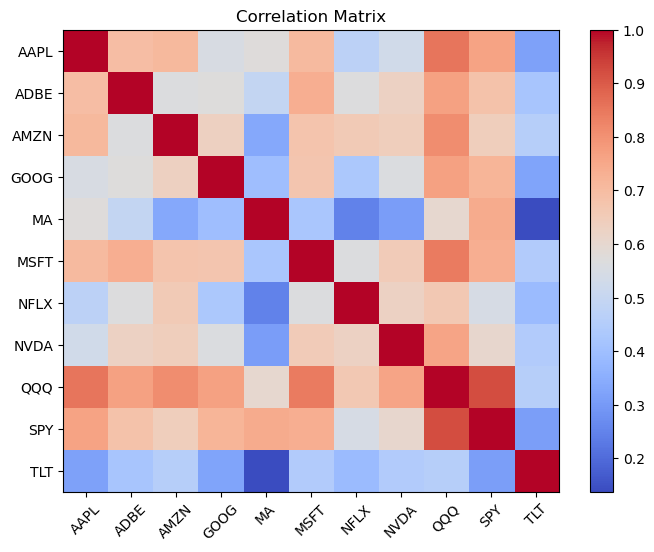

In [17]:
# Calculate the correlations between all the monthly returns of stocks with eachother
correlations = monthly_ret.corr()

# ** Code to Display Heat Map **

plt.figure(figsize=(8, 6))
plt.imshow(correlations, cmap='coolwarm', interpolation='none', aspect='auto')
plt.colorbar()

# Add labels for the axes
tick_marks = np.arange(len(correlations.columns))
plt.xticks(tick_marks, correlations.columns, rotation=45)
plt.yticks(tick_marks, correlations.columns)

plt.title('Correlation Matrix')
plt.show()

## Case Study: Airbus vs Boeing

Lets now used what we have done over the course of this notebook to explore the relationship between Airbus and Boeing.

Tickers: 'BA' and 'EADSY'

In [18]:
# Load in the data for both stocks:

tickers = ['BA', 'EADSY']

data = yf.download(
    tickers = tickers, # The stocks do we want to get
    interval = "1d", # The sample rate of the data
    start="2020-05-01", # From what point do we want to start getting stock data
    end="2024-04-30", # From what point do we want to stop getting stock data
    ignore_tz=True,
    auto_adjust=True, # Adjust all fields by splits and dividends
)

data.head()

[*********************100%***********************]  2 of 2 completed


Price            Close                   High                    Low  \
Ticker              BA      EADSY          BA      EADSY          BA   
Date                                                                   
2020-05-01  133.369995  14.301344  143.710007  14.759061  132.839996   
2020-05-04  131.460007  14.142545  131.500000  14.142545  124.349998   
2020-05-05  125.400002  14.039790  133.800003  14.656308  125.000000   
2020-05-06  121.860001  13.441956  126.860001  13.955720  121.370003   
2020-05-07  128.649994  14.235955  130.710007  14.366732  122.360001   

Price                        Open               Volume           
Ticker          EADSY          BA      EADSY        BA    EADSY  
Date                                                             
2020-05-01  14.142544  143.229996  14.142544  36613100   425000  
2020-05-04  13.563392  127.120003  13.628780  30708900   680600  
2020-05-05  14.021108  132.880005  14.516190  30621000   784100  
2020-05-06  13.423273  125.800003  13.946379  29627700   582900  
2020-05-07  13.694167  122.809998  13.731532  29525000  1213800

In [19]:
# Take the close values
df = data['Close'].copy()

In [20]:
df.describe()

Ticker,BA,EADSY
count,1005.000000,1005.000000
mean,196.513642,28.567661
std,32.407425,6.242668
min,115.860001,12.517178
25%,174.279999,25.501415
50%,203.380005,28.789509
75%,217.470001,32.021557
max,269.190002,44.747150


In [21]:
# Compute Daily returns and fill NaN values
df = df.pct_change().fillna(0)

# Resample the data, grouping it into months for the monthly returns to be computed
monthly_ret = df.resample('ME')

# Apply our custom function to these months
monthly_ret = monthly_ret.apply(lambda x: (1 + x).prod() - 1)

# Display data
monthly_ret.head()

Ticker,BA,EADSY
Date,,
2020-05-31,0.093574,0.044415
2020-06-30,0.256771,0.116323
2020-07-31,-0.138025,0.015686
2020-08-31,0.087468,0.135687
2020-09-30,-0.038180,-0.119476


In [22]:
# Let's see what the worse month was for both companies...

ba_min = monthly_ret['BA'].min()
ba_min_index = monthly_ret['BA'].idxmin()

print(f'The worse Boeing day was a {round((ba_min * 100), 2)}% decrese in Boeing Stock on {ba_min_index.month_name()} {ba_min_index.year}')

ab_min = monthly_ret['EADSY'].min()
ab_min_index = monthly_ret['EADSY'].idxmin()

print(f'The worse Airbus day was a {round((ab_min * 100), 2)}% decrese in Airbus Stock on {ab_min_index.month_name()} {ab_min_index.year}')

The worse Boeing day was a -24.44% decrese in Boeing Stock on September 2022
The worse Airbus day was a -16.9% decrese in Airbus Stock on June 2022


#### What happened in those months?

**In September 2022:** Boeing announced a $200 million settlement with the U.S. Securities and Exchange Commission (SEC) over charges that the company misled investors about the safety of the 737 Max.

**In June 2022:** Shares in aircraft manufacturer Airbus (AIR) posted the biggest fall on the Paris Bourse after the company issued a profit warning due to problems with its supply chains and asset write-downs. At 10:42 UK time, the share price was down 11.2% at EUR 132.84 (£112.27).


In [23]:
# Calculate the final returns over the time period
cumulative_ret = (1 + monthly_ret).cumprod()

In [24]:
# Import in a custom plotting library
import plotly.express as px

# Let's plot the monthly returns of both these stocks
px.line(cumulative_ret)

In [25]:
# We can use the cumulative return values to estimate how much we would had made if we invested £100 in Airbus and Boeing from July 2020 to Feb 2024

invested = 100 # Let's say we invested £100
final_cumulative_ret = cumulative_ret.iloc[-1] # Get the final cumulative return value

stock_value_airbus = invested * final_cumulative_ret['EADSY']
stock_value_boeing = invested * final_cumulative_ret['BA']

print(f'Value of the orginal £100 pound investment if it had been invested in Airbus: £{round(stock_value_airbus, 2)}')
print(f'Value of the orginal £100 pound investment if it had been invested in Boeing: £{round(stock_value_boeing, 2)}')

Value of the orginal £100 pound investment if it had been invested in Airbus: £284.75
Value of the orginal £100 pound investment if it had been invested in Boeing: £130.08


### Risk Anaylsis
Let's have a look at the best ways for us to identify and calculate the risk of an asset. One way to do that is to look at the standard deviation of a stock over time.


In [26]:
# Get the std of the monthly returns:
risk = monthly_ret.std()

print('The risk of investing in Airbus is: ', round(risk['EADSY'], 4))
print('The risk of investing in Boeing is: ', round(risk['BA'], 4))

The risk of investing in Airbus is:  0.1038
The risk of investing in Boeing is:  0.134


We can see that the standard deviation of the monthly returns for Airbus is far lower than Boeing which is exactly what we would expect. Airbus is a less risky investment.

# Challenge:

In this notebook we have explore some data exploration technqiues and touched on some basic mathematical approaches for analysing stocks.

**Your task**: Is to find/choose two stocks that you like, and calculate the best time to buy/sell these specific stocks, and then further calculate when the best time would be to buy both stocks at the same time.